# Group 2: Luca Milani, Marta Laskowska, Monika Kaczorowska

### Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
import requests
import bs4 as bs
import yfinance as yf
import datetime


from ipywidgets import interact, IntSlider, Checkbox
from functools import lru_cache
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

### Dataset

In [3]:
df = pd.read_csv("Data_PCLab1_Stock.csv", parse_dates=["Date"])
df = df.sort_values("Date").set_index("Date")
df.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-12,60.198570,75.510002,30.120001,12.13,175.929993,180.550003,28.250000,313.644379,1295.500000
2012-01-13,59.972858,74.599998,30.070000,12.35,178.419998,179.160004,22.790001,311.328064,1289.089966
2012-01-17,60.671429,75.239998,30.250000,12.25,181.660004,180.000000,26.600000,313.116364,1293.670044
2012-01-18,61.301430,75.059998,30.330000,12.73,189.440002,181.070007,26.809999,315.273285,1308.040039
2012-01-19,61.107143,75.559998,30.420000,12.80,194.449997,180.520004,26.760000,318.590851,1314.500000


### Task #1: Visualization and 1st step toward the CAPM

#### Daily returns

In [4]:
daily_returns = df.pct_change()
daily_returns = df.pct_change() * 100
daily_returns = daily_returns.iloc[1:]
daily_returns.head()

,AAPL,BA,T,MGM,AMZN,IBM,TSLA,GOOG,sp500
Date,,,,,,,,,
2012-01-13,-0.374946,-1.205144,-0.166006,1.813685,1.415339,-0.769869,-19.327430,-0.738516,-0.494792
2012-01-17,1.164812,0.857909,0.598603,-0.809717,1.815943,0.468852,16.717854,0.574410,0.355295
2012-01-18,1.038382,-0.239234,0.264463,3.918367,4.282725,0.594448,0.789470,0.688856,1.110793
2012-01-19,-0.316937,0.666134,0.296736,0.549882,2.644634,-0.303752,-0.186494,1.052283,0.493866
2012-01-20,-1.741670,-0.052939,0.295858,-1.250000,-1.810236,4.431642,-0.597907,-8.377507,0.066946


#### Scatter Plots of daily returns against the market daily returns

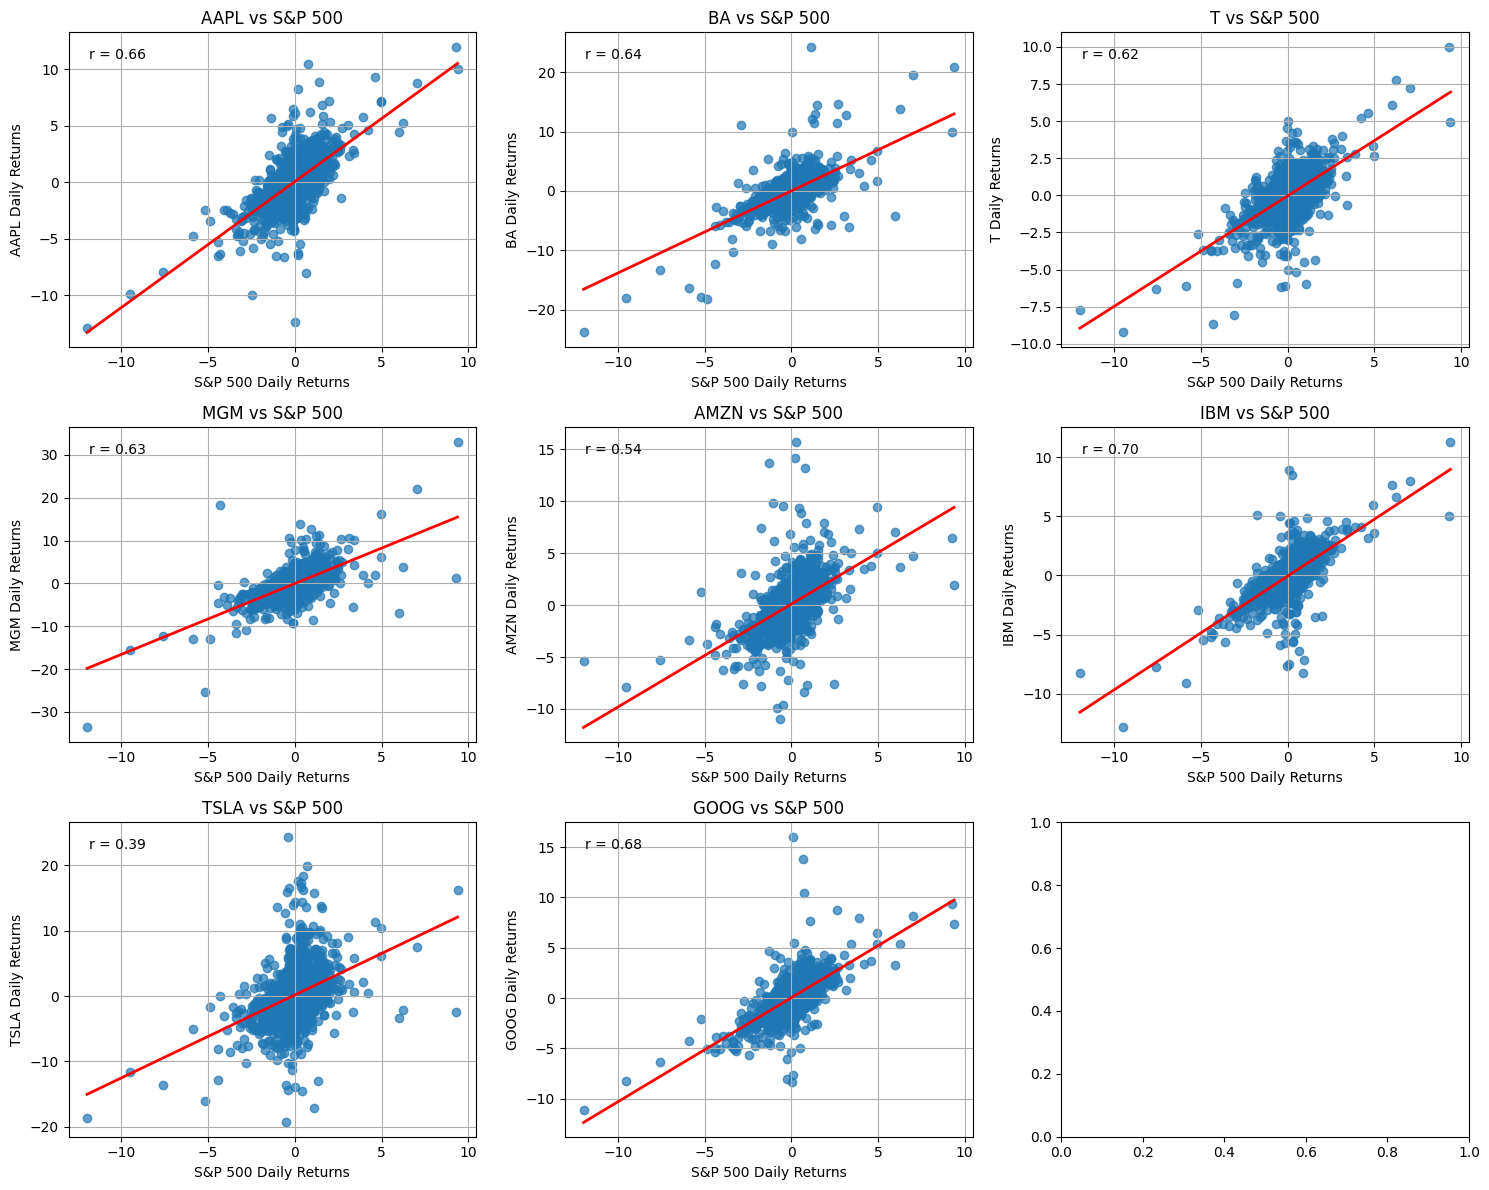

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(daily_returns.columns):
    if col != "sp500":
        ax = axes[i]

        x = daily_returns["sp500"].to_numpy(dtype=float)
        y = daily_returns[col].to_numpy(dtype=float)

        # scatter
        ax.scatter(x, y, alpha=0.7)

        if x.size >= 2 and np.ptp(x) > 0:
            # regression line
            m, b = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            ax.plot(x_line, m * x_line + b, color="red", linewidth=2)

            # correlation coefficient
            r = np.corrcoef(x, y)[0, 1]
            ax.text(0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes,
                    fontsize=10, verticalalignment="top")

        ax.set_xlabel("S&P 500 Daily Returns")
        ax.set_ylabel(f"{col} Daily Returns")
        ax.set_title(f"{col} vs S&P 500")
        ax.grid(True)

plt.tight_layout()
plt.show()

For the majority of the stocks, the correlation of the daily returns with the benchmark (S&P 500) is relatively strong, especially for Google, Apple and IBM where the correlation is greater than 0.65.

The above-mentioned companies play a crucial role in the S&P 500 index, therefore changes in returns for each of the stocks individually, impact the changes of the market daily returns.

### Task #2: Compute alpha and beta

#### Apply the CAPM : run an OLS regression of stock i returns on market returns, over the whole period. Assume rf = 0. Are the estimates significant?

In [6]:
market = daily_returns["sp500"]
stocks = [c for c in daily_returns.columns if c != "sp500"]

rows = []
residuals = {}

for s in stocks:
    y = daily_returns[s].astype(float).to_numpy()
    X = sm.add_constant(market.astype(float).to_numpy())
    model = sm.OLS(y, X, missing="drop").fit()

    rows.append({
        "stock": s,
        "alpha(%)": model.params[0],
        "beta": model.params[1],
        "t(alpha)": model.tvalues[0],
        "p(alpha)": model.pvalues[0],
        "t(beta)": model.tvalues[1],
        "p(beta)": model.pvalues[1],
        "R2": model.rsquared,
        "nobs": int(model.nobs)
    })

    residuals[s] = model.resid

summary = pd.DataFrame(rows).set_index("stock").sort_values("beta", ascending=False)
summary.round(4)


,alpha(%),beta,t(alpha),p(alpha),t(beta),p(beta),R2,nobs
stock,,,,,,,,
MGM,-0.0169,1.6536,-0.3679,0.7130,37.8118,0.0,0.3987,2158
BA,-0.0023,1.3829,-0.0613,0.9511,38.8625,0.0,0.4119,2158
TSLA,0.1759,1.2686,2.5809,0.0099,19.5425,0.0,0.1505,2158
AAPL,0.0528,1.1129,1.8312,0.0672,40.4999,0.0,0.4321,2158
GOOG,0.0334,1.0349,1.3392,0.1807,43.6062,0.0,0.4686,2158
AMZN,0.1023,0.9917,2.9222,0.0035,29.7563,0.0,0.2911,2158
IBM,-0.0535,0.9604,-2.4405,0.0147,46.0190,0.0,0.4955,2158
T,-0.0286,0.7446,-1.3322,0.1829,36.4486,0.0,0.3813,2158


- **Betas (β):**
  - All stocks have **highly significant β (p < 0.001)** → market returns strongly explain stock returns.  
  - MGM (1.65) and BA (1.38) are **riskier than the market** (β > 1).  
  - AAPL (1.11) and GOOG (1.03) are close to market risk (β ≈ 1).  
  - IBM (0.96) and T (0.74) are **defensive stocks**, less sensitive to the market.  

- **Alphas (α):**
  - TSLA (0.176%, p = 0.0099) and AMZN (0.102%, p = 0.0035) have **positive and significant α** → they delivered returns beyond what CAPM predicts.  
  - IBM (-0.0535%, p = 0.0147) has a **negative and significant α** → underperformance relative to CAPM expectations.  
  - AAPL and GOOG have **positive but insignificant α** → not statistically different from zero.  
  - MGM, BA, T have α ≈ 0 and **insignificant** → consistent with CAPM’s prediction that α should vanish

- **R² (goodness of fit):**
  - Highest for IBM (0.495), GOOG (0.468), AAPL (0.432) → **well explained by the market**.  
  - Lowest for TSLA (0.150) → **most idiosyncratic risk**, confirming that Tesla’s volatility is not captured by market beta alone.  

**Comment:**  
Statistical tests reinforce the CAPM intuition: β is always significant and measures systematic risk, while α should be ≈ 0. Deviations (TSLA, AMZN, IBM) may reflect either real mispricing or omitted risk factors


#### Plot the beta and alpha for the 8 stocks. Which stock has the highest (lowest) beta and alpha? Comment!

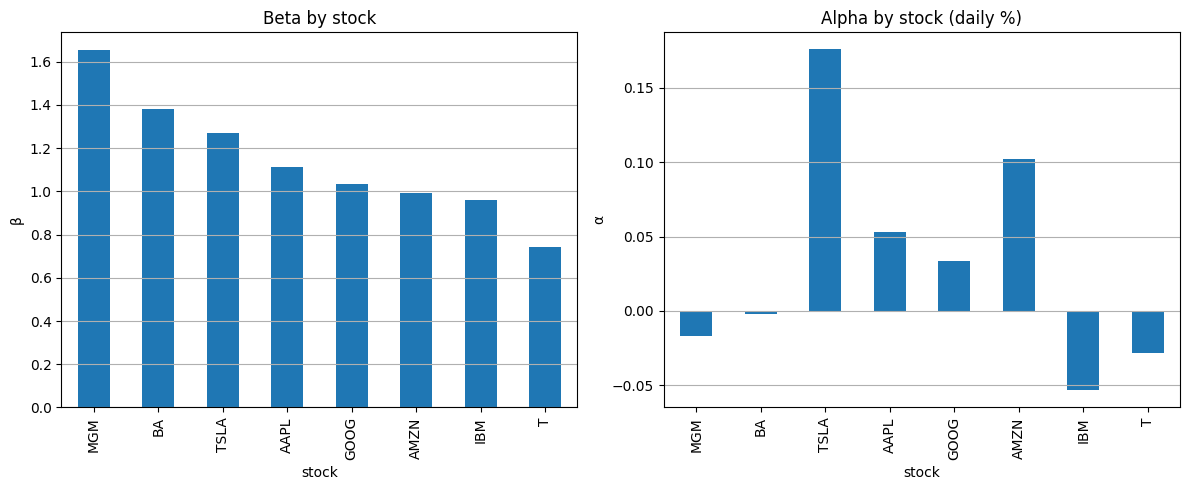

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

summary["beta"].plot(kind="bar", ax=ax[0])
ax[0].set_title("Beta by stock")
ax[0].set_ylabel("β")
ax[0].grid(True, axis="y")

summary["alpha(%)"].plot(kind="bar", ax=ax[1])
ax[1].set_title("Alpha by stock (daily %)")
ax[1].set_ylabel("α")
ax[1].grid(True, axis="y")

plt.tight_layout()
plt.show()

- **Beta chart:** 
  - High-β stocks (MGM, BA) are **cyclical** and react strongly to market conditions.  
  - Low-β stocks (IBM, T) are more **defensive**.  

- **Alpha chart:**  
  - TSLA is a clear outlier with a large positive α, suggesting **persistent outperformance**.  
  - AMZN also shows positive α.  
  - IBM exhibits **negative α**, i.e. underperformance relative to CAPM expectations.  


#### Use the observed returns and the predicted ones to compute and plot the histogram of error terms εi for each stock. Comment!

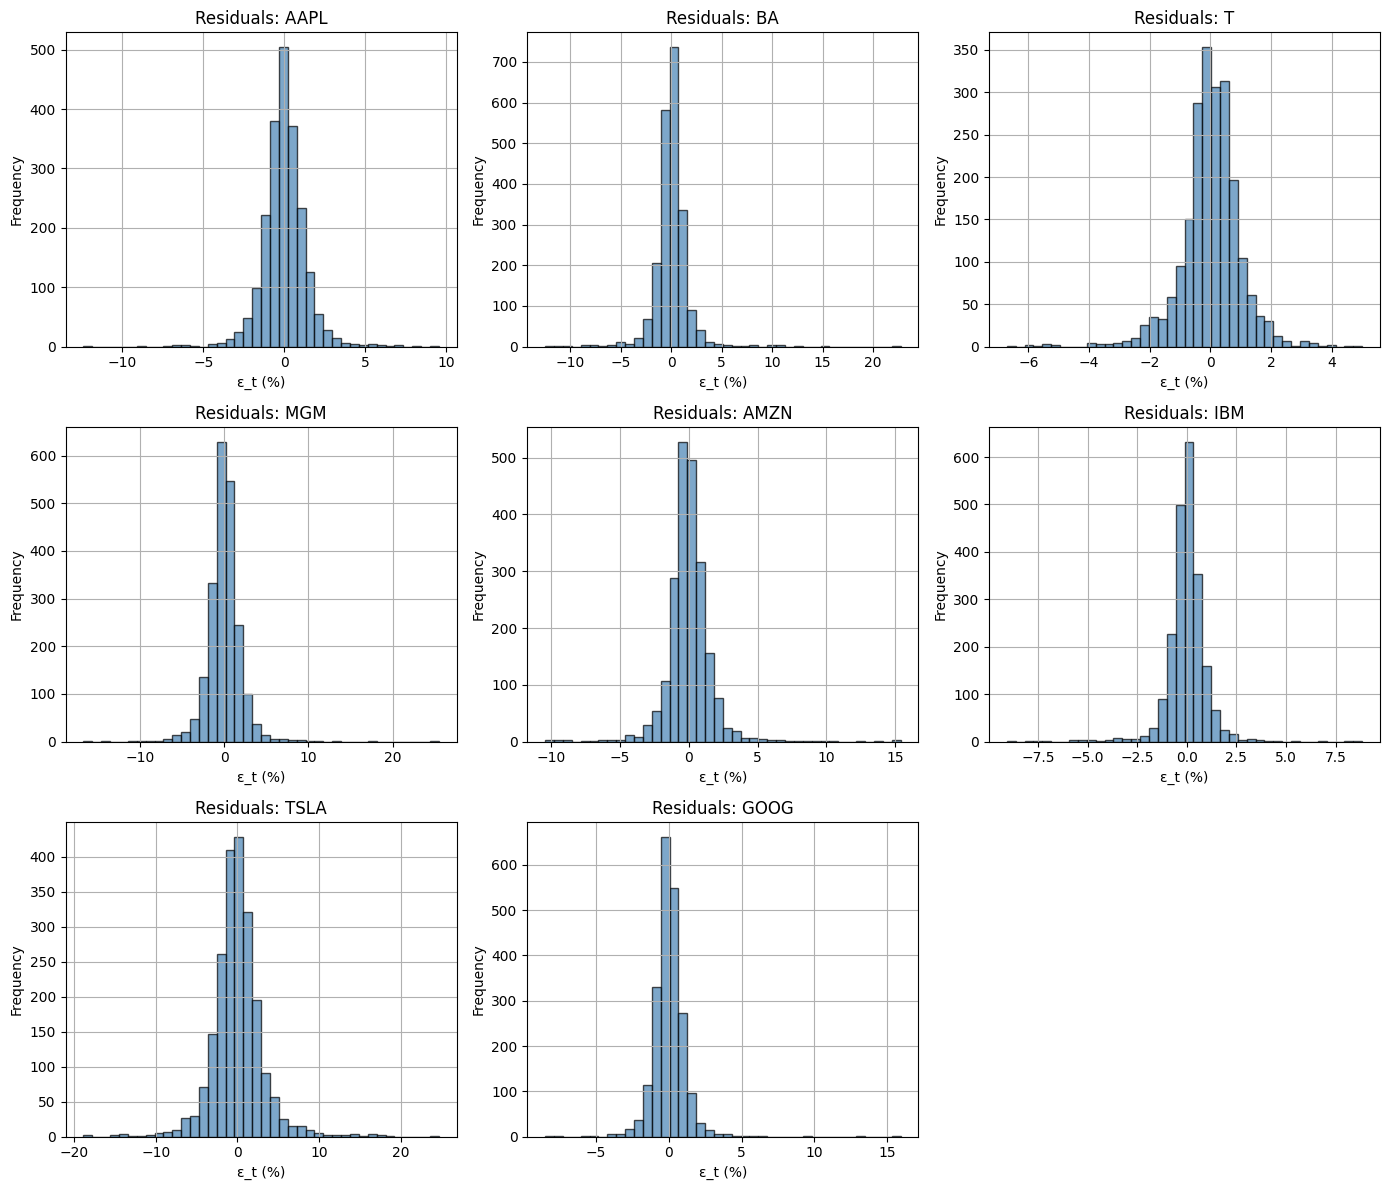

In [13]:
cols = 3
rows_ = int(np.ceil(len(stocks) / cols))
fig, axes = plt.subplots(rows_, cols, figsize=(14, 4 * rows_))
axes = np.array(axes).reshape(-1)

# Adjust bins so histograms are flatter / shorter
num_bins = 40

for i, s in enumerate(stocks):
    axes[i].hist(residuals[s], bins=num_bins, alpha=0.7, color="steelblue", edgecolor="black")
    axes[i].set_title(f"Residuals: {s}")
    axes[i].set_xlabel("ε_t (%)")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

- Residuals are centered around zero (as expected).  
- MGM and TSLA have **fatter tails**, reflecting extreme firm-specific events not explained by CAPM.  
- IBM, GOOG, AAPL show tighter residual distributions → market explains them better.  


#### Your boss wants to take a lot of risk to deliver high return. He asks you to (i) select the 4 riskier assets (over the full period), (ii) form an equally weighted portfolio, and (iii) to estimate the portfolio return based on parameters (β and rm) estimated above.

Running on both a Alpha = 0 (under CAPM) and Alpha = mean (realistic)

In [9]:
# Select 4 highest-beta stocks
top4 = summary.head(4).index.tolist()
print("Top 4 by beta:", top4)

# compute equal-weight portfolio beta
beta_p = summary.loc[top4, "beta"].mean()

# Market average daily return (in %)
rm_bar = market.mean()

# ---------- VERSION A: Pure CAPM (alpha = 0) ----------
alpha_CAPM = 0
R_p_CAPM = beta_p * rm_bar

# ---------- VERSION B: Empirical Regression (include alpha) ----------
alpha_empirical = summary.loc[top4, "alpha(%)"].mean()
R_p_REG = alpha_empirical + beta_p * rm_bar

#  results
print("\nEqual-weight risky portfolio (daily % returns):")
print(f"  beta_p = {beta_p:.3f}")
print(f"  market mean return = {rm_bar:.4f}%")

print("\n--- CAPM prediction (alpha=0) ---")
print(f"  alpha_p = {alpha_CAPM:.4f}%")
print(f"  Predicted portfolio return = {R_p_CAPM:.4f}%")

print("\n--- Regression-based prediction (with alpha) ---")
print(f"  alpha_p = {alpha_empirical:.4f}%")
print(f"  Predicted portfolio return = {R_p_REG:.4f}%")


Top 4 by beta: ['MGM', 'BA', 'TSLA', 'AAPL']

Equal-weight risky portfolio (daily % returns):
  beta_p = 1.354
  market mean return = 0.0493%

--- CAPM prediction (alpha=0) ---
  alpha_p = 0.0000%
  Predicted portfolio return = 0.0668%

--- Regression-based prediction (with alpha) ---
  alpha_p = 0.0524%
  Predicted portfolio return = 0.1192%


- The 4 riskiest stocks (by β) are **MGM, BA, TSLA, and AAPL**.  
- The equal-weight portfolio has a **β = 1.354**, meaning it is ~35% more volatile than the market.  
- The average market daily return is **0.0493%**.

**Predictions:**
- **CAPM (α=0):** Expected portfolio return = **0.0668% per day**.  
- **Regression (with α):** Including the average α (0.0524%) raises the predicted return to **0.1192% per day**.

**Takeaway:**  
Under CAPM, the portfolio earns higher expected returns because of its high β.  
Empirical regression suggests even greater performance, driven by positive alphas from some stocks.


### Task #3 : Testing the CAPM theory

 #### 1. For each year: compute $\beta_i^{y-1}$ over 252 business days at the end of each year $y-1$ (OLS regression).

In [10]:
def ols_alpha_beta(y, x):
    """
    OLS: y = alpha + beta * x + eps
    y, x = daily % returns aligned on same dates.
    Returns (alpha, beta, R2).
    """
    data = pd.concat([y, x], axis=1).dropna()
    X = sm.add_constant(data.iloc[:, 1].to_numpy(float))
    y_vals = data.iloc[:, 0].to_numpy(float)
    model = sm.OLS(y_vals, X).fit()
    return model.params[0], model.params[1], model.rsquared

In [11]:
def compute_prior_year_betas(daily_returns, window=252):
    """
    For each year y, compute beta_i^{y-1} using the last `window`
    trading days of year (y-1).
    """
    years = sorted(daily_returns.index.year.unique())
    stocks = [c for c in daily_returns.columns if c != "sp500"]

    rows = []
    for y in years[1:]:  # need prior year
        # last date of year y-1
        prev_end = daily_returns.loc[str(y-1)].index.max()
        # last 252 rows before prev_end
        win_idx = daily_returns.loc[:prev_end].tail(window).index
        x_win = daily_returns.loc[win_idx, "sp500"]

        for s in stocks:
            y_win = daily_returns.loc[win_idx, s]
            alpha, beta, r2 = ols_alpha_beta(y_win, x_win)
            rows.append({"year": y, "stock": s,
                         "alpha_prior": alpha,
                         "beta_prior": beta,
                         "R2": r2})
    return pd.DataFrame(rows).set_index(["year", "stock"]).sort_index()

beta_prior_df = compute_prior_year_betas(daily_returns)
beta_prior_df

alpha_prior  beta_prior        R2
year stock                                   
2013 AAPL      0.058931    1.283028  0.303144
     AMZN      0.118027    1.123074  0.204914
     BA       -0.037814    1.024616  0.484401
     GOOG      0.021343    0.860334  0.240239
     IBM      -0.007105    0.856619  0.454210
     MGM      -0.066087    1.732747  0.382294
     T         0.024070    0.616265  0.308387
     TSLA      0.063814    1.611417  0.147229
2014 AAPL     -0.028697    0.626566  0.059003
     AMZN      0.065110    1.265466  0.268729
     BA        0.143001    0.966673  0.254269
     GOOG      0.092319    0.945169  0.227874
     IBM      -0.081999    0.765491  0.205818
     MGM       0.135566    1.526288  0.334542
     T        -0.061124    0.784543  0.309745
     TSLA      0.558150    1.174505  0.036699
2015 AAPL      0.098483    0.835490  0.192024
     AMZN     -0.144831    1.463360  0.266677
     BA       -0.058290    1.021059  0.360434
     GOOG     -0.073561    1.279824  0.470680
     IBM      -0.089206    0.729346  0.233774
     MGM      -0.086839    1.492332  0.302354
     T        -0.039597    0.564327  0.197669
     TSLA      0.114534    1.900735  0.200061
2016 AAPL     -0.006842    1.145075  0.440406
     AMZN      0.328755    1.119326  0.266875
     BA        0.049738    0.999672  0.507757
     GOOG      0.160943    1.084603  0.324416
     IBM      -0.053755    1.019357  0.550925
     MGM       0.050995    1.479366  0.348391
     T         0.013320    0.721119  0.483661
     TSLA      0.057857    1.136643  0.205542
2017 AAPL      0.008823    1.009962  0.320262
     AMZN      0.014481    1.116334  0.242218
     BA       -0.007124    1.217194  0.435686
     GOOG     -0.023046    0.952996  0.390212
     IBM       0.045338    0.931592  0.380449
     MGM       0.049168    1.669338  0.461376
     T         0.069600    0.476372  0.178073
     TSLA     -0.064176    1.215942  0.168734
2018 AAPL      0.057829    1.378480  0.272840
     AMZN      0.084621    1.328988  0.178819
     BA        0.190838    0.994291  0.140160
     GOOG      0.031500    1.273356  0.302259
     IBM      -0.073968    0.664028  0.079091
     MGM      -0.023366    1.417016  0.146654
     T        -0.083603    0.760486  0.084821
     TSLA      0.077995    1.356536  0.066240
2019 AAPL      0.011562    1.255978  0.554731
     AMZN      0.155014    1.624503  0.588081
     BA        0.081735    1.311033  0.505252
     GOOG      0.040846    1.370261  0.690222
     IBM      -0.087147    0.966826  0.442714
     MGM      -0.073456    1.355074  0.400926
     T        -0.100097    0.660046  0.227506
     TSLA      0.117958    1.379974  0.161487
2020 AAPL      0.098825    1.558167  0.550987
     AMZN     -0.045114    1.327099  0.521965
     BA       -0.081259    0.981311  0.178649
     GOOG     -0.021103    1.290719  0.444647
     IBM      -0.037792    1.075293  0.421725
     MGM       0.000501    1.336059  0.398892
     T         0.071693    0.577960  0.149612
     TSLA      0.002354    1.317051  0.110927

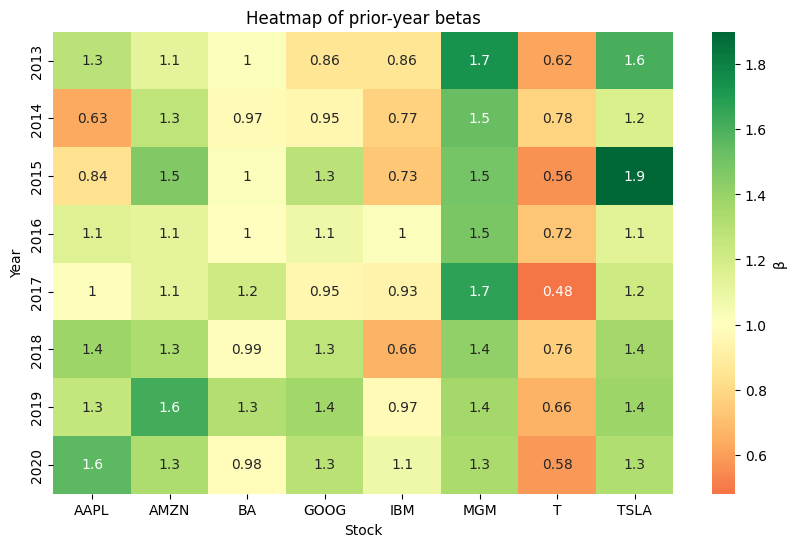

In [12]:
beta_wide = beta_prior_df.reset_index().pivot(index="year", columns="stock", values="beta_prior")

plt.figure(figsize=(10,6))
sns.heatmap(beta_wide.round(2), annot=True, cmap="RdYlGn", center=1.0, cbar_kws={"label": "β"})
plt.title("Heatmap of prior-year betas")
plt.ylabel("Year"); plt.xlabel("Stock")
plt.show()


- MGM and TSLA frequently show high betas (>1.5) → they are consistently more volatile and sensitive to the market.

- T (AT&T) often has the lowest betas (<0.7) → it is the most defensive stock in this set.

- AAPL, AMZN, GOOG, and BA hover closer to 1–1.3, reflecting risk similar to or slightly above the market.

- Shifts over time are visible (e.g., AMZN’s beta rising in later years, TSLA staying high, MGM decreasing slightly.)

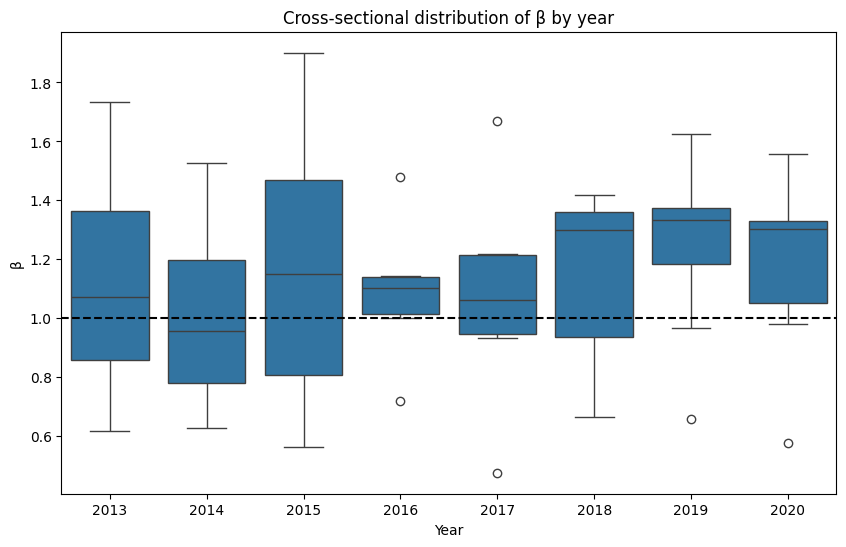

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(x="year", y="beta_prior", data=beta_prior_df.reset_index())
plt.axhline(1.0, linestyle="--", color="black")
plt.title("Cross-sectional distribution of β by year")
plt.ylabel("β"); plt.xlabel("Year")
plt.show()


- Most betas cluster around 1, but the spread varies across years.

- In some years (2013, 2015), the dispersion is wide: some stocks are very defensive (β < 0.7) while others are highly aggressive (β > 1.7).

- In other years (2016–2017), betas are more compressed, suggesting stocks were moving more in line with the market.

- The median beta is usually slightly above 1, meaning the “average stock” is a bit riskier than the market.

#### 2. At the end of year $y$, compare the average return of the stock $\bar{r}_i^y$ (annualized) to the one predicted by the CAPM model $\hat{r}_i^y$  (using $\beta_i^{y-1}$ measured at $y-1$, but the average market return $\bar{r}_M^y$ measured at $y$).


In [14]:
def annualize_from_daily_percent(daily_pct: pd.Series, trading_days=252) -> float:
    """
    Geometric annualization from daily % returns.
    """
    r = (daily_pct.dropna() / 100.0).to_numpy()
    if r.size == 0:
        return np.nan
    gross = np.prod(1.0 + r)
    return (gross ** (trading_days / r.size) - 1.0) * 100.0  # back to %

# Build realized annualized returns for each stock i and the market in year y
def realized_annualized_returns(daily_returns: pd.DataFrame) -> pd.DataFrame:
    years = sorted(daily_returns.index.year.unique())
    stocks = [c for c in daily_returns.columns if c != "sp500"]

    rows = []
    for y in years:
        yr = daily_returns.loc[str(y)]
        if yr.empty:
            continue
        rM_y = annualize_from_daily_percent(yr["sp500"])  # market annualized
        for s in stocks:
            ri_y = annualize_from_daily_percent(yr[s])     # stock annualized
            rows.append({"year": y, "stock": s,
                         "r_realized_ann(%)": ri_y,
                         "rM_ann(%)": rM_y})
    return pd.DataFrame(rows).set_index(["year", "stock"]).sort_index()

realized_df = realized_annualized_returns(daily_returns)
realized_df

r_realized_ann(%)  rM_ann(%)
year stock                              
2012 AAPL           27.513113  10.526074
     AMZN           44.702812  10.526074
     BA             -0.206851  10.526074
     GOOG           12.888512  10.526074
     IBM             6.352086  10.526074
     MGM            -4.202939  10.526074
     T              12.440968  10.526074
     TSLA           20.796067  10.526074
2013 AAPL            5.421202  29.601250
     AMZN           58.962816  29.601250
     BA             81.117308  29.601250
     GOOG           58.431118  29.601250
     IBM            -2.077784  29.601250
     MGM           102.061856  29.601250
     T               4.301397  29.601250
     TSLA          344.139349  29.601250
2014 AAPL           37.724142  11.390634
     AMZN          -22.177086  11.390634
     BA             -4.769587  11.390634
     GOOG           -5.965611  11.390634
     IBM           -14.463936  11.390634
     MGM            -9.098644  11.390634
     T              -4.465301  11.390634
     TSLA           47.849508  11.390634
2015 AAPL           -4.638517  -0.726600
     AMZN          117.783149  -0.726600
     BA             11.240191  -0.726600
     GOOG           44.559933  -0.726600
     IBM           -14.223390  -0.726600
     MGM             6.267540  -0.726600
     T               2.441203  -0.726600
     TSLA            7.913309  -0.726600
2016 AAPL           10.032299   9.535023
     AMZN           10.945565   9.535023
     BA              7.669961   9.535023
     GOOG            1.705145   9.535023
     IBM            20.614744   9.535023
     MGM            26.892611   9.535023
     T              23.597788   9.535023
     TSLA          -10.966207   9.535023
2017 AAPL           46.335580  19.504434
     AMZN           56.232735  19.504434
     BA             89.916241  19.504434
     GOOG           35.740151  19.504434
     IBM            -7.601743  19.504434
     MGM            15.884629  19.504434
     T              -8.614848  19.504434
     TSLA           45.920372  19.504434
2018 AAPL           -6.815678  -6.261315
     AMZN           28.559783  -6.261315
     BA              9.394366  -6.261315
     GOOG           -1.035245  -6.261315
     IBM           -25.997735  -6.261315
     MGM           -27.435919  -6.261315
     T             -26.685012  -6.261315
     TSLA            6.917723  -6.261315
2019 AAPL           86.160761  28.878070
     AMZN           23.027757  28.878070
     BA              1.010856  28.878070
     GOOG           29.104590  28.878070
     IBM            17.920292  28.878070
     MGM            37.139324  28.878070
     T              36.930626  28.878070
     TSLA           25.700121  28.878070
2020 AAPL           92.014131   5.264928
     AMZN          130.802936   5.264928
     BA            -62.073351   5.264928
     GOOG           18.128912   5.264928
     IBM            -8.744600   5.264928
     MGM           -51.053461   5.264928
     T             -34.413722   5.264928
     TSLA          600.375133   5.264928

In [15]:
# Join prior-year betas (from Task 3.1) with realized returns of year y
panel = beta_prior_df.join(realized_df, how="inner")

# CAPM prediction:  r_hat_i^y = beta_i^{y-1} * rM^y   (assume r_f = 0)
panel["r_capm_pred_ann(%)"] = panel["beta_prior"] * panel["rM_ann(%)"]

# Prediction error (realized minus predicted)
panel["prediction_error(%)"] = panel["r_realized_ann(%)"] - panel["r_capm_pred_ann(%)"]

panel.round(3).head(12)


alpha_prior  beta_prior     R2  r_realized_ann(%)  rM_ann(%)  \
year stock                                                                 
2013 AAPL         0.059       1.283  0.303              5.421     29.601   
     AMZN         0.118       1.123  0.205             58.963     29.601   
     BA          -0.038       1.025  0.484             81.117     29.601   
     GOOG         0.021       0.860  0.240             58.431     29.601   
     IBM         -0.007       0.857  0.454             -2.078     29.601   
     MGM         -0.066       1.733  0.382            102.062     29.601   
     T            0.024       0.616  0.308              4.301     29.601   
     TSLA         0.064       1.611  0.147            344.139     29.601   
2014 AAPL        -0.029       0.627  0.059             37.724     11.391   
     AMZN         0.065       1.265  0.269            -22.177     11.391   
     BA           0.143       0.967  0.254             -4.770     11.391   
     GOOG         0.092       0.945  0.228             -5.966     11.391   

            r_capm_pred_ann(%)  prediction_error(%)  
year stock                                           
2013 AAPL               37.979              -32.558  
     AMZN               33.244               25.718  
     BA                 30.330               50.787  
     GOOG               25.467               32.964  
     IBM                25.357              -27.435  
     MGM                51.291               50.770  
     T                  18.242              -13.941  
     TSLA               47.700              296.439  
2014 AAPL                7.137               30.587  
     AMZN               14.414              -36.592  
     BA                 11.011              -15.781  
     GOOG               10.766              -16.732

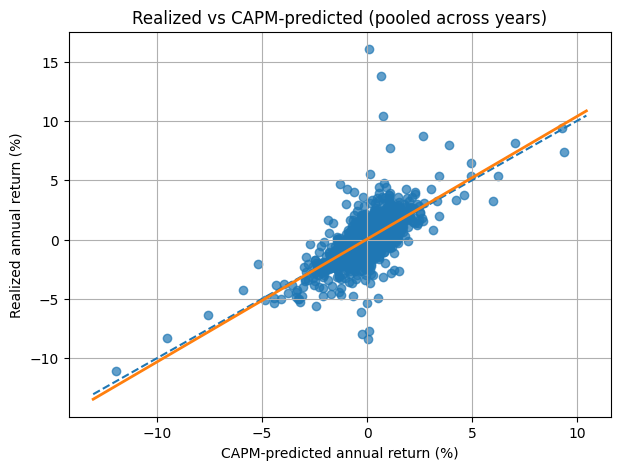

In [16]:
m = np.isfinite(x) & np.isfinite(y)
xv, yv = x[m], y[m]

plt.figure(figsize=(7,5))
plt.scatter(xv, yv, alpha=0.7)

x_min, x_max = np.nanmin(xv), np.nanmax(xv)
pad = 0.05 * (x_max - x_min if x_max > x_min else 1.0)
x_line = np.linspace(x_min - pad, x_max + pad, 200)
plt.plot(x_line, x_line, linestyle="--")  # 45-degree

# Regression line y = a + b x
import statsmodels.api as sm
fit = sm.OLS(yv, sm.add_constant(xv)).fit()
plt.plot(x_line, fit.params[0] + fit.params[1]*x_line, linewidth=2)

plt.xlabel("CAPM-predicted annual return (%)")
plt.ylabel("Realized annual return (%)")
plt.title("Realized vs CAPM-predicted (pooled across years)")
plt.grid(True)

**Interpretation:**  
The 45° dashed line represents the case where realized returns equal CAPM-predicted returns.   The regression line (orange) lies close to this benchmark, with a positive slope, which suggests that higher CAPM-predicted returns are generally associated with higher realized returns.  

However, the dispersion of points around the line is wide, and the fit is not very tight.   This indicates that while CAPM-predicted returns provide *some* directional guidance, they explain only a small fraction of the variation in realized returns.   One possible explanation is that returns are influenced by other risk factors (size, value, momentum, etc.) or by firm-specific events that CAPM does not capture.   This is consistent with empirical evidence that the CAPM often struggles to account for cross-sectional differences in returns.


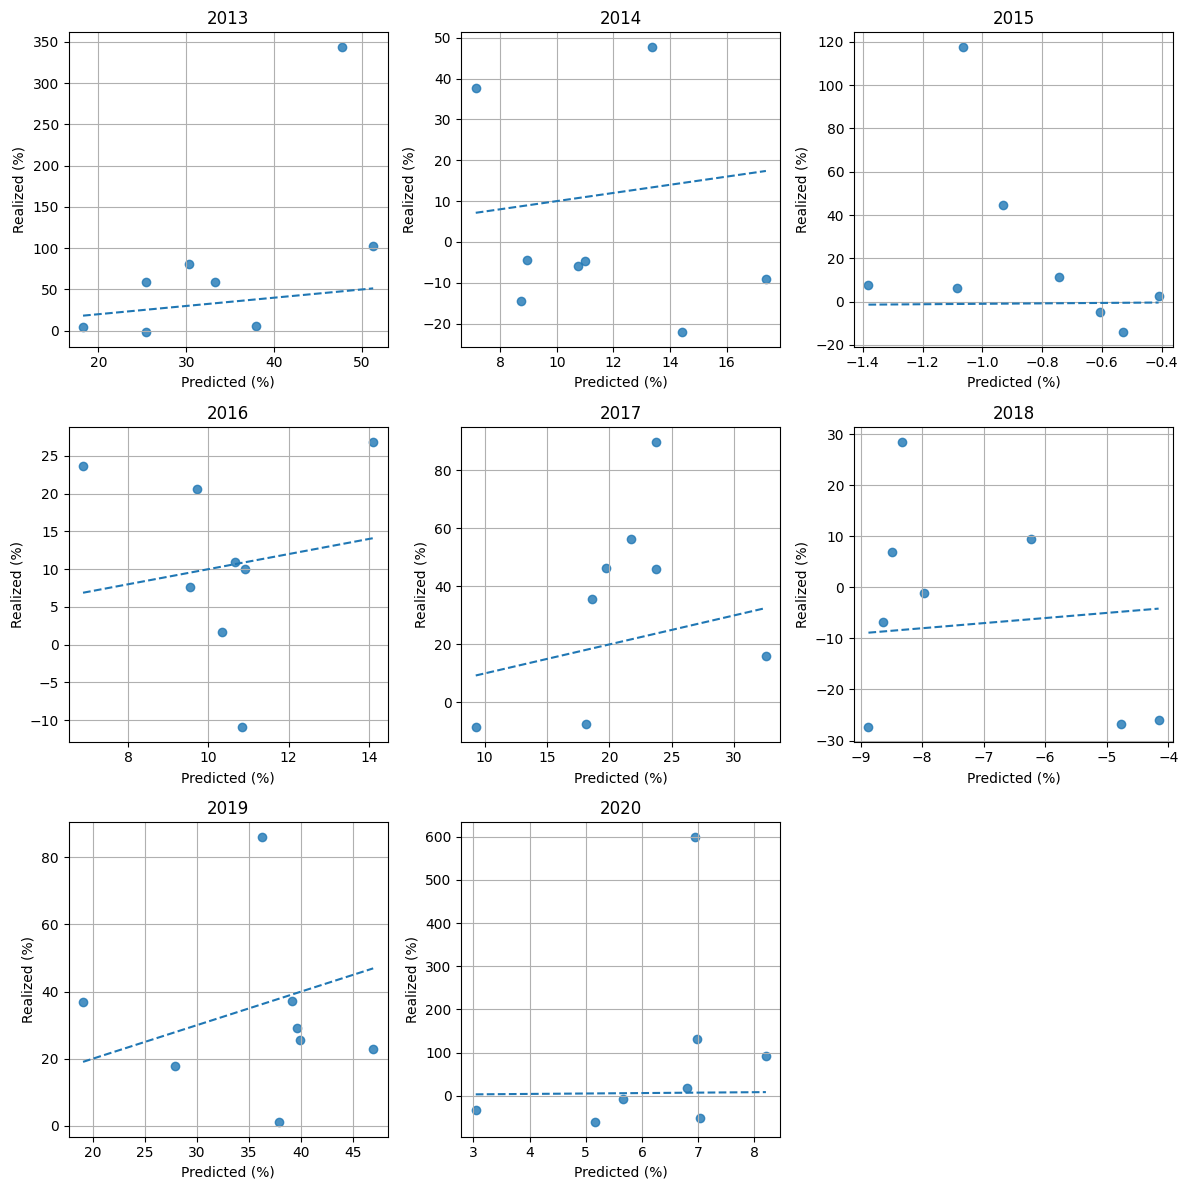

In [17]:
years = sorted(panel.index.get_level_values(0).unique())
n = len(years)
cols = 3
rows = (n + cols - 1)//cols
fig, axes = plt.subplots(rows, cols, figsize=(12,4*rows)); axes = axes.ravel()

for i, y_ in enumerate(years):
    sub = panel.loc[y_]
    xv = sub["r_capm_pred_ann(%)"].to_numpy(); yv = sub["r_realized_ann(%)"].to_numpy()
    m = np.isfinite(xv) & np.isfinite(yv)
    ax = axes[i]
    ax.scatter(xv[m], yv[m], alpha=0.8)
    # 45°
    xl = np.linspace(np.min(xv[m]), np.max(xv[m]), 100)
    ax.plot(xl, xl, linestyle="--")
    ax.set_title(str(y_)); ax.set_xlabel("Predicted (%)"); ax.set_ylabel("Realized (%)"); ax.grid(True)

for j in range(i+1, len(axes)): axes[j].axis("off")
plt.tight_layout(); plt.show()


**Interpretation:**  
The plots illustrate how the relationship between realized returns and CAPM-predicted returns changes across years:

- **2013, 2015, 2017:** Slopes are positive, meaning stocks with higher predicted returns tended to have higher realized returns. However, the scatter is wide, suggesting only weak explanatory power.  
- **2014, 2018, 2019:** The slopes are flatter, and in some cases slightly negative. This implies that CAPM predictions were less aligned with realized outcomes in those years.  
- **2016:** The relationship looks somewhat tighter, with realized returns moving more consistently with predictions.  
- **2020:** Realized returns are extremely dispersed (one outlier are far above the rest), which overwhelms the fitted line. This reflects that extraordinary events (e.g., COVID-19) likely drove firm-specific shocks that CAPM cannot capture.

**Overall:**  
Across years, the explanatory power of CAPM appears inconsistent — in some periods it aligns reasonably with realized returns, but in others the predictions do not track actual outcomes well.  
One possible explanation is that market conditions, macro shocks, and omitted risk factors (like size or value effects) dominate in certain years, making β an unreliable predictor on its own.


#### 3. Generate the scatter plot of the realized returns against the betas, or find innovative ways to visualize your results.


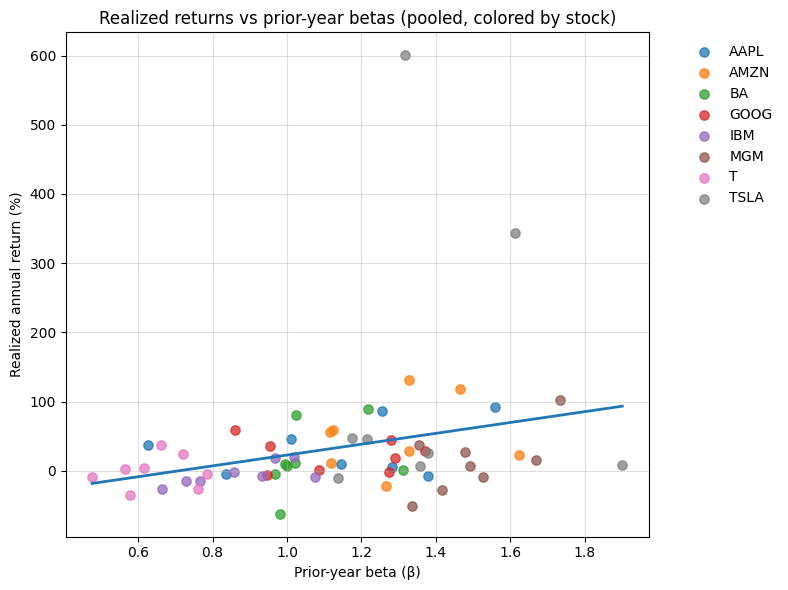

Slope (pooled): 78.356   R^2 (pooled): 0.075


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

df_scatter = panel.reset_index()[["stock","beta_prior","r_realized_ann(%)"]]
stocks = sorted(df_scatter["stock"].unique())

# consistent colors per stock
cmap = plt.get_cmap("tab10")
color_map = {s: cmap(i % 10) for i, s in enumerate(stocks)}

plt.figure(figsize=(8,6))
for s in stocks:
    sub = df_scatter[df_scatter["stock"] == s]
    plt.scatter(sub["beta_prior"], sub["r_realized_ann(%)"],
                alpha=0.75, s=45, label=s, color=color_map[s])

# overall regression line (realized on beta)
x = df_scatter["beta_prior"].to_numpy()
y = df_scatter["r_realized_ann(%)"].to_numpy()
m = np.isfinite(x) & np.isfinite(y)
X = sm.add_constant(x[m])
fit = sm.OLS(y[m], X).fit()
xx = np.linspace(np.nanmin(x[m]), np.nanmax(x[m]), 200)
plt.plot(xx, fit.params[0] + fit.params[1]*xx, linewidth=2)

plt.xlabel("Prior-year beta (β)")
plt.ylabel("Realized annual return (%)")
plt.title("Realized returns vs prior-year betas (pooled, colored by stock)")
plt.grid(True, alpha=0.4)

# Legend outside
plt.legend(
    ncol=1,
    frameon=False,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


print(f"Slope (pooled): {fit.params[1]:.3f}   R^2 (pooled): {fit.rsquared:.3f}")


**Interpretation:**  
The regression line shows a positive slope, suggesting that stocks with higher prior-year betas tended, on average, to earn somewhat higher realized returns.  
However, the relationship is weak — points are widely scattered, and the explanatory power is low.  

Some stocks, such as Tesla (grey), show extreme realized returns (both very high and very negative in some years), which create large outliers.  
Defensive stocks like AT&T (pink) cluster around lower betas (<1) and generally lower realized returns, while cyclical stocks such as MGM and BA spread out more widely.  

Overall, the plot indicates that β may carry some information about future returns, but the signal is noisy and inconsistent.  
One explanation could be that realized returns are driven not just by systematic risk (β) but also by firm-specific shocks and additional risk factors (e.g., value, growth, momentum).  
This aligns with the broader evidence that CAPM’s single-factor approach has limited ability to explain cross-sectional returns.


#### Based on the preivous results, rerunning the graph but excluding tesla since it has been shown to violate capm a lot

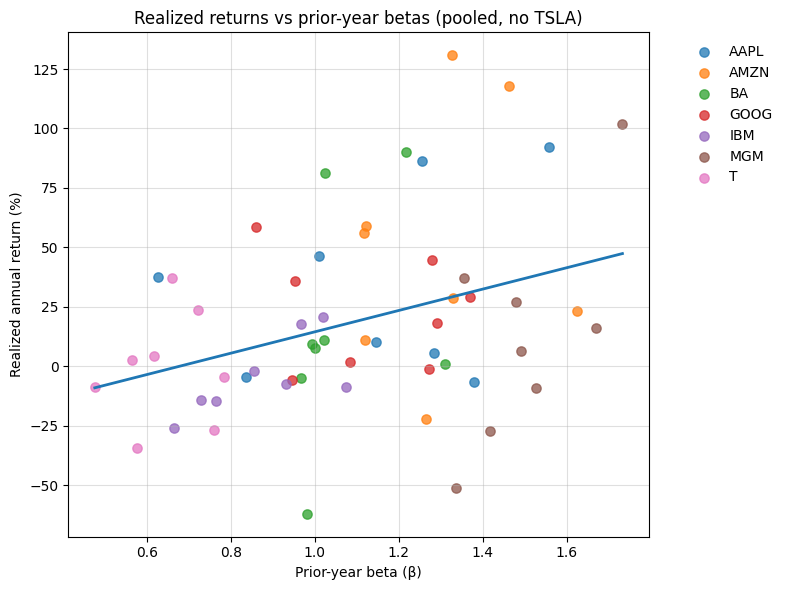

Slope (pooled, no TSLA): 44.947   R^2: 0.121


In [19]:

# ========= EXCLUDE TESLA =========
df_no_tsla = df_scatter[df_scatter["stock"] != "TSLA"].copy()

# Colors (rebuild without TSLA)
stocks = sorted(df_no_tsla["stock"].unique())
cmap = plt.get_cmap("tab10")
color_map = {s: cmap(i % 10) for i, s in enumerate(stocks)}

plt.figure(figsize=(8,6))

# Points per stock (no TSLA)
for s in stocks:
    sub = df_no_tsla[df_no_tsla["stock"] == s]
    plt.scatter(
        sub["beta_prior"], sub["r_realized_ann(%)"],
        alpha=0.75, s=45, label=s, color=color_map[s]
    )

# ========= REGRESSION (no TSLA) =========
x = df_no_tsla["beta_prior"].to_numpy()
y = df_no_tsla["r_realized_ann(%)"].to_numpy()
m = np.isfinite(x) & np.isfinite(y)
X = sm.add_constant(x[m])
fit = sm.OLS(y[m], X).fit()

# Fitted line
xx = np.linspace(np.nanmin(x[m]), np.nanmax(x[m]), 200)
yy = fit.params[0] + fit.params[1]*xx
plt.plot(xx, yy, linewidth=2)

plt.xlabel("Prior-year beta (β)")
plt.ylabel("Realized annual return (%)")
plt.title("Realized returns vs prior-year betas (pooled, no TSLA)")
plt.grid(True, alpha=0.4)

# Legend outside
plt.legend(
    ncol=1,
    frameon=False,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

print(f"Slope (pooled, no TSLA): {fit.params[1]:.3f}   R^2: {fit.rsquared:.3f}")


**Interpretation (with vs. without Tesla):**

- **With Tesla (top panel):**  
  The regression slope is steeper (≈78) but the explanatory power is low (R² ≈ 0.075).  
  This reflects that Tesla’s extreme realized returns exert a strong pull on the regression line, but because they are outliers, they do not improve the fit for most other stocks.

- **Without Tesla (bottom panel):**  
  The slope becomes smaller (≈45), but R² rises (≈0.121).  
  This suggests that the overall relationship between β and realized returns becomes *tighter* once Tesla’s outsized influence is removed.  
  The data look more balanced across stocks, and the regression line better reflects the central tendency of the sample.

**Takeaway:**  
Tesla’s extreme realized returns act as influential outliers — they inflate the slope but weaken the fit across the rest of the sample.  
When excluded, the CAPM β–return relationship appears more stable, though still noisy.  


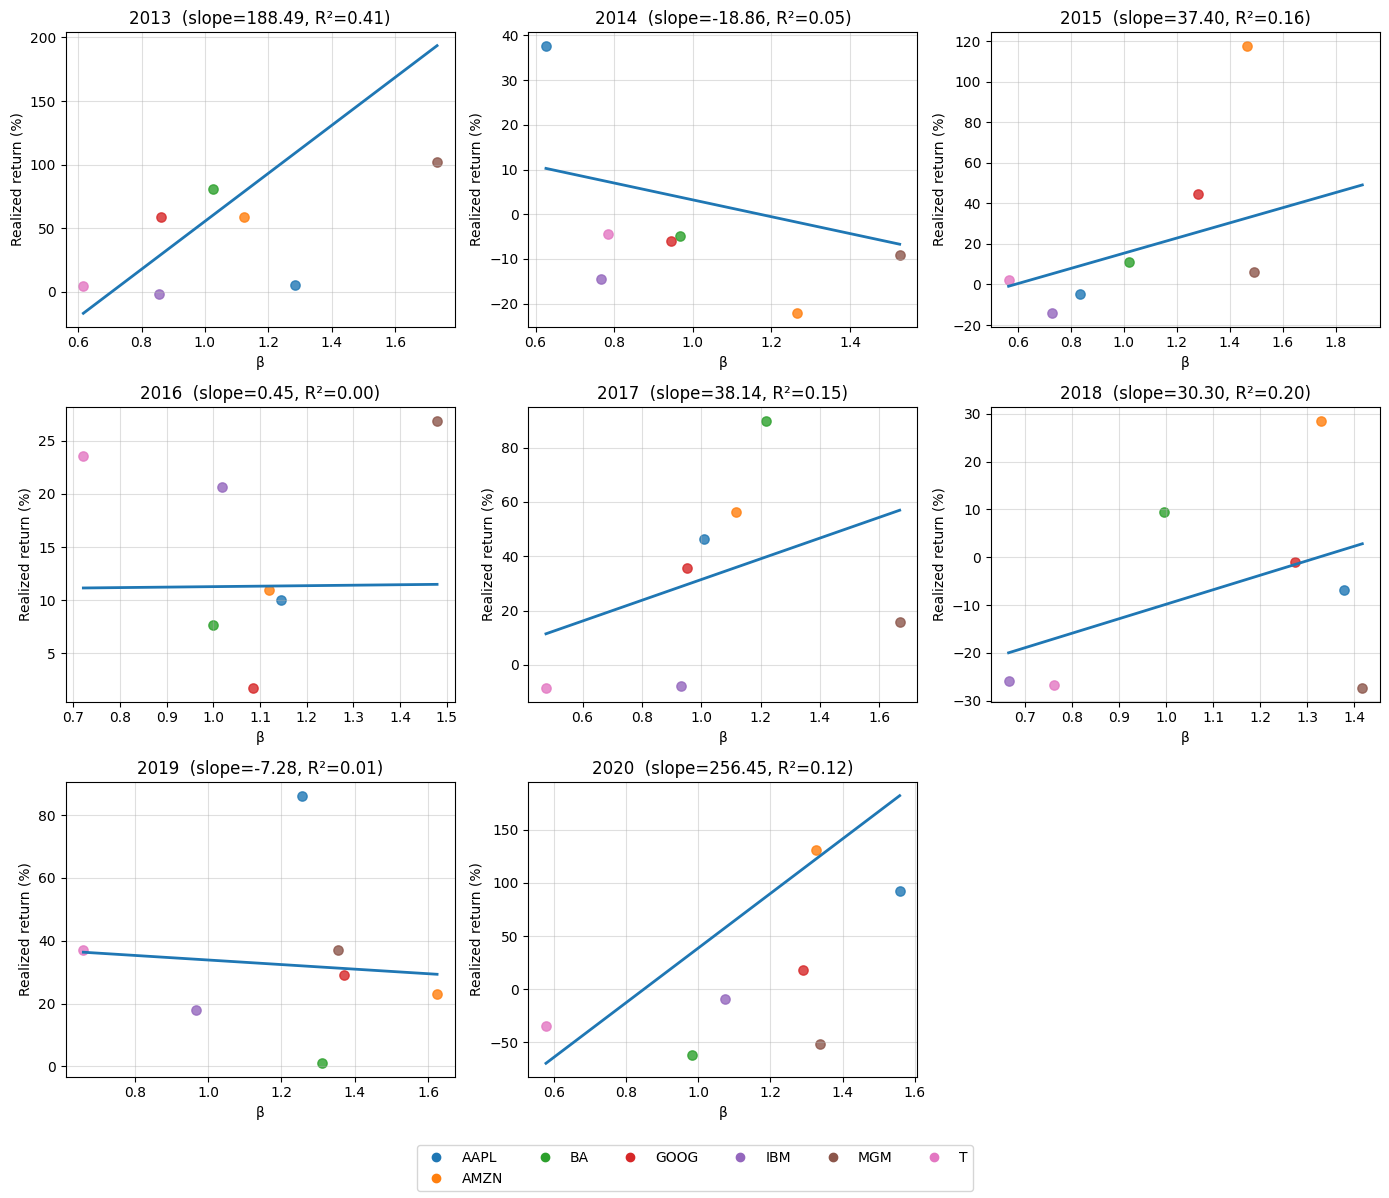

In [20]:

years = sorted(panel.index.get_level_values(0).unique())
df_scatter_y = panel.reset_index()[["year","stock","beta_prior","r_realized_ann(%)"]]

cols = 3
rows = math.ceil(len(years) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(14, 4*rows), squeeze=False)

for i, y in enumerate(years):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    sub = df_scatter_y[df_scatter_y["year"] == y]

    # plot points by stock with consistent colors
    for s in stocks:
        ss = sub[sub["stock"] == s]
        if not ss.empty:
            ax.scatter(ss["beta_prior"], ss["r_realized_ann(%)"],
                       alpha=0.8, s=45, color=color_map[s])

    # regression per year
    x = sub["beta_prior"].to_numpy()
    yv = sub["r_realized_ann(%)"].to_numpy()
    m = np.isfinite(x) & np.isfinite(yv)
    if m.sum() >= 3:
        X = sm.add_constant(x[m])
        fit = sm.OLS(yv[m], X).fit()
        xx = np.linspace(np.nanmin(x[m]), np.nanmax(x[m]), 100)
        ax.plot(xx, fit.params[0] + fit.params[1]*xx, linewidth=2)
        ax.set_title(f"{int(y)}  (slope={fit.params[1]:.2f}, R²={fit.rsquared:.2f})")
    else:
        ax.set_title(f"{int(y)}")

    ax.grid(True, alpha=0.4)
    ax.set_xlabel("β"); ax.set_ylabel("Realized return (%)")

# hide any empty subplots
for j in range(i+1, rows*cols):
    r, c = divmod(j, cols)
    axes[r, c].axis("off")

# single shared legend below the grid
handles = [plt.Line2D([0],[0], marker='o', linestyle='', color=color_map[s], label=s) for s in stocks]
fig.legend(handles=handles, labels=stocks, loc="lower center", ncol=min(6, len(stocks)))
plt.tight_layout(rect=[0,0.05,1,1])
plt.show()


**Interpretation:**  
The yearly plots highlight how unstable the CAPM β–return relationship can be across different market environments:

- **2013, 2015, 2017, 2018, 2020:** Slopes are positive, suggesting that in these years higher β stocks tended to deliver higher realized returns. However, the strength of the fit varies: 2013 shows a strong slope with moderate R², while 2016 and 2020 show very noisy outcomes despite positive slopes.  
- **2014, 2019:** Slopes are negative, indicating that higher β stocks underperformed relative to lower β ones in those years. This contradicts CAPM’s prediction.  
- **2016:** The slope is nearly flat with R² ≈ 0, showing no apparent relationship between β and returns.  
- **2020:** The slope is very steep due to extreme observations (notably Tesla), but R² is still low, reflecting wide dispersion around the line.

**Overall pattern:**  
- The direction and strength of the β–return link changes year by year, with some years showing weak or even inverted relationships.  
- The generally low R² values imply that β alone explains little of the variation in realized returns within a given year.  
- This variability supports the idea that CAPM, as a single-factor model, has limited explanatory power in real-world data and that additional factors (size, value, momentum, etc.) may be needed for more stable predictions.


#### 4. Alternatively, you may use a $\beta$ computed over longer (or shorter) periods of time.


In [21]:
# windows shorter & longer than baseline 252
windows = [63, 126, 252, 504]

# realized returns (stock + market) by year
realized_df = realized_annualized_returns(daily_returns)  # index: (year, stock)

def fit_metrics(df, xcol="r_capm_pred_ann(%)", ycol="r_realized_ann(%)"):
    x = df[xcol].to_numpy()
    y = df[ycol].to_numpy()
    m = np.isfinite(x) & np.isfinite(y)
    X = sm.add_constant(x[m])
    fit = sm.OLS(y[m], X).fit()
    resid = y[m] - fit.predict(X)
    out = {
        "slope": float(fit.params[1]),
        "R2": float(fit.rsquared),
        "MAE(%)": float(np.mean(np.abs(resid))),
        "RMSE(%)": float(np.sqrt(np.mean(resid**2))),
        "n": int(m.sum())
    }
    return out, fit, m

# gather panels + metrics
panels = {}
metrics_rows = []

for w in windows:
    betas_w = compute_prior_year_betas(daily_returns, window=w)  # (year, stock)
    pan = betas_w.join(realized_df, how="inner")
    pan["r_capm_pred_ann(%)"] = pan["beta_prior"] * pan["rM_ann(%)"]
    pan["prediction_error(%)"] = pan["r_realized_ann(%)"] - pan["r_capm_pred_ann(%)"]

    (mrow, fit, mask) = fit_metrics(pan)
    mrow["window"] = w
    metrics_rows.append(mrow)
    panels[w] = (pan, fit, mask)

metrics = pd.DataFrame(metrics_rows).set_index("window").sort_index()
print(metrics.round(3))


        slope     R2  MAE(%)  RMSE(%)   n
window                                   
63      0.537  0.009  45.285   89.964  64
126     0.944  0.026  44.100   89.172  64
252     1.335  0.052  42.277   87.999  64
504     1.358  0.052  42.139   87.983  64


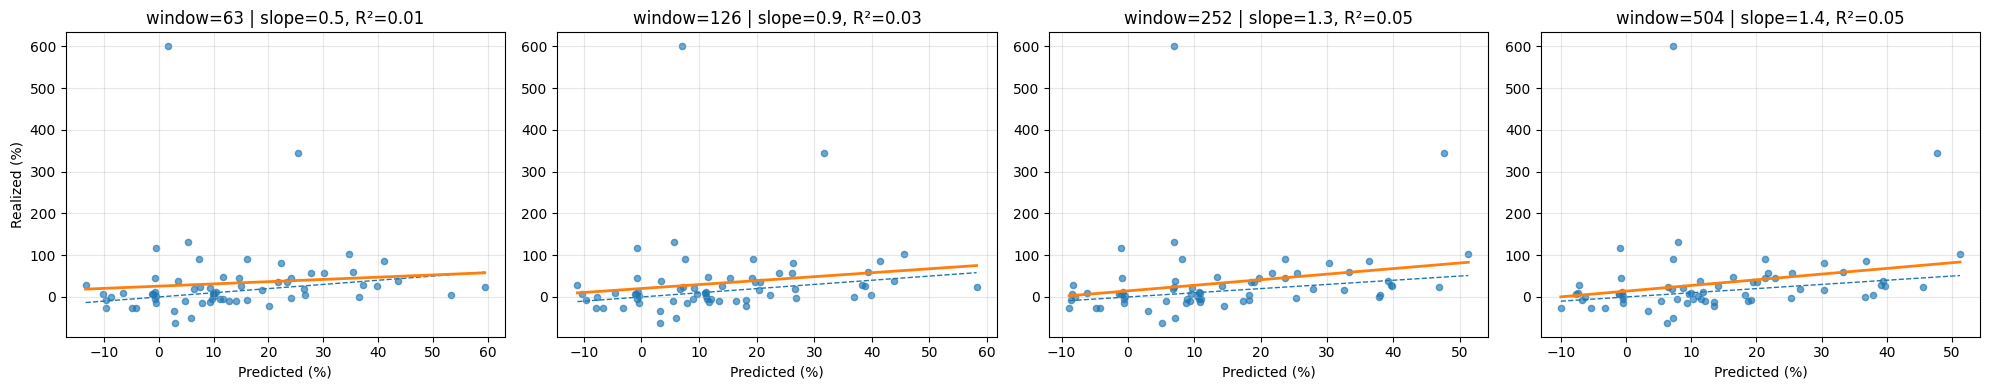

In [22]:
# One scatter per window: realized vs predicted, 45° line + regression
nW = len(windows)
fig, axes = plt.subplots(1, nW, figsize=(5*nW, 4), squeeze=False)

for j, w in enumerate(windows):
    pan, fit, m = panels[w]
    ax = axes[0, j]
    x = pan["r_capm_pred_ann(%)"].to_numpy(); y = pan["r_realized_ann(%)"].to_numpy()
    ax.scatter(x[m], y[m], alpha=0.65, s=20)
    xx = np.linspace(np.nanmin(x[m]), np.nanmax(x[m]), 200)
    ax.plot(xx, xx, linestyle="--", linewidth=1)  # 45°
    ax.plot(xx, fit.params[0] + fit.params[1]*xx, linewidth=2)  # regression

    ax.set_title(f"window={w} | slope={fit.params[1]:.1f}, R²={fit.rsquared:.2f}")
    ax.set_xlabel("Predicted (%)")
    if j == 0: ax.set_ylabel("Realized (%)")
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


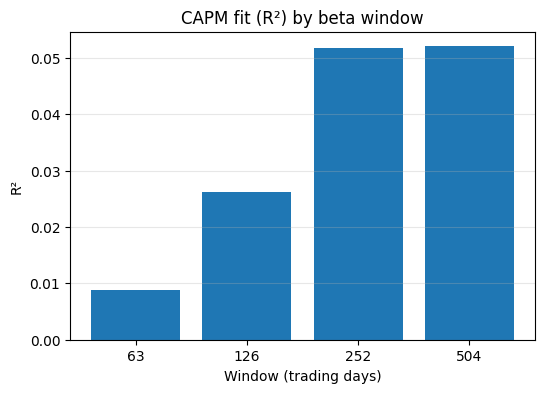

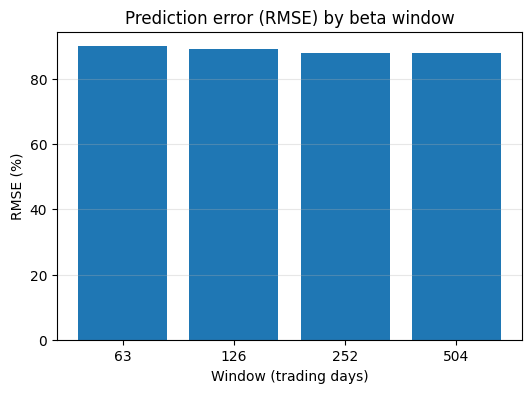

In [23]:
# R² by window
plt.figure(figsize=(6,4))
plt.bar([str(w) for w in metrics.index], metrics["R2"].values)
plt.title("CAPM fit (R²) by beta window")
plt.xlabel("Window (trading days)")
plt.ylabel("R²")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# RMSE by window
plt.figure(figsize=(6,4))
plt.bar([str(w) for w in metrics.index], metrics["RMSE(%)"].values)
plt.title("Prediction error (RMSE) by beta window")
plt.xlabel("Window (trading days)")
plt.ylabel("RMSE (%)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


**Task 3.4 – Interpretation (different β windows):**  
The estimation window influences the slope and fit of the CAPM regressions.  
- Very short windows (63, 126 trading days) produce noisier betas, yielding almost no explanatory power.  
- Longer windows (252, 504 days) give slightly stronger slopes and marginally higher R², but overall fit remains weak.  
- RMSE is large and stable across all windows, showing that prediction errors are substantial no matter how β is estimated.  

One explanation could be that CAPM’s single β factor captures only a small part of return variation, while firm-specific shocks and additional risk factors dominate. The choice of window alters the smoothness of β estimates but does not fundamentally change CAPM’s limited predictive ability.


#### 5. Comment on your results in the light of yesterday’s lecture: try to give as much economic interpretation as you can!


The pooled and year-by-year results suggest that prior-year β has a **positive but weak** association with realized returns. One possible explanation is that β captures exposure to broad market risk, but realized outcomes also depend on **additional risk factors** (size, value, momentum) and **firm-specific news** that CAPM does not model.  


Years such as **2014 and 2019** show flat or negative β–return slopes, while **2013, 2015, 2017, 2018** show positive slopes, and **2020** is dominated by large outliers. One interpretation is that **macro shocks** (e.g., COVID-19) and sector-specific cycles intermittently dominate, making β a less reliable cross-sectional predictor in those periods.

Finally, excluding **TSLA** reduces the influence of extreme observations and often improves fit slightly, which could indicate that part of the weak CAPM performance owes to **idiosyncratic extremes** rather than the model’s structure alone. Overall, these patterns align with the view that **single-factor CAPM is a useful benchmark but incomplete**, motivating multi-factor models in practice.


### Optional Task : Obtain data from the web

Web-scrapping : get the list of S&P 500 tickers from Wikipedia

In [24]:


url = 'http://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) '
                  'Chrome/111.0.0.0 Safari/537.36'
}

resp = requests.get(url, headers=headers) 
soup = bs.BeautifulSoup(resp.text, 'lxml')

table = soup.find('table', {'id': 'constituents'})
tickers = []

for row in table.find_all('tr')[1:]:  
    cols = row.find_all('td')
    if cols:  
        ticker = cols[0].text.strip()
        tickers.append(ticker)

print(len(tickers))  
tickers

503


['MMM',
 'AOS',
 'ABT',
 'ABBV',
 'ACN',
 'ADBE',
 'AMD',
 'AES',
 'AFL',
 'A',
 'APD',
 'ABNB',
 'AKAM',
 'ALB',
 'ARE',
 'ALGN',
 'ALLE',
 'LNT',
 'ALL',
 'GOOGL',
 'GOOG',
 'MO',
 'AMZN',
 'AMCR',
 'AEE',
 'AEP',
 'AXP',
 'AIG',
 'AMT',
 'AWK',
 'AMP',
 'AME',
 'AMGN',
 'APH',
 'ADI',
 'AON',
 'APA',
 'APO',
 'AAPL',
 'AMAT',
 'APP',
 'APTV',
 'ACGL',
 'ADM',
 'ANET',
 'AJG',
 'AIZ',
 'T',
 'ATO',
 'ADSK',
 'ADP',
 'AZO',
 'AVB',
 'AVY',
 'AXON',
 'BKR',
 'BALL',
 'BAC',
 'BAX',
 'BDX',
 'BRK.B',
 'BBY',
 'TECH',
 'BIIB',
 'BLK',
 'BX',
 'XYZ',
 'BK',
 'BA',
 'BKNG',
 'BSX',
 'BMY',
 'AVGO',
 'BR',
 'BRO',
 'BF.B',
 'BLDR',
 'BG',
 'BXP',
 'CHRW',
 'CDNS',
 'CPT',
 'CPB',
 'COF',
 'CAH',
 'KMX',
 'CCL',
 'CARR',
 'CAT',
 'CBOE',
 'CBRE',
 'CDW',
 'COR',
 'CNC',
 'CNP',
 'CF',
 'CRL',
 'SCHW',
 'CHTR',
 'CVX',
 'CMG',
 'CB',
 'CHD',
 'CI',
 'CINF',
 'CTAS',
 'CSCO',
 'C',
 'CFG',
 'CLX',
 'CME',
 'CMS',
 'KO',
 'CTSH',
 'COIN',
 'CL',
 'CMCSA',
 'CAG',
 'COP',
 'ED',
 'STZ',
 'CEG',


Use the list of tickers as input in the yfinance package (an API that gives
 access to Yahoo Finance data)

In [25]:
tickers = [s.replace('.','-') for s in tickers]

start = datetime.datetime(2020, 1, 1)
data = yf.download(tickers, start=start, end=None)

/var/folders/vp/3w5dj_l159g93tb2308ztr7r0000gn/T/ipykernel_64964/1784683764.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start, end=None)
[*********************100%***********************]  503 of 503 completed

1 Failed download:
['BF-B']: OperationalError('database is locked')


In [ ]:
data

 Describe and comment the data. Why do you have more variables than in the
 PCLab_Data.xlsx file?